In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
stocks = ['BUMI.JK', 'DEWA.JK', 'BBCA.JK' , 'PTBA.JK','PTRO.JK','MINA.JK']
endDate = pd.to_datetime('today')
startDate = endDate - pd.DateOffset(years=5)

getData = yf.download(stocks, start = startDate, end= endDate)
Data = getData['Close'].dropna()
Data.head()

[*********************100%***********************]  6 of 6 completed


Ticker,BBCA.JK,BUMI.JK,DEWA.JK,MINA.JK,PTBA.JK,PTRO.JK
Date,,,,,,
2021-03-05,5997.505371,60.0,50.0,55.0,1208.208984,134.656281
2021-03-08,5926.946289,59.0,50.0,57.0,1194.833862,135.775314
2021-03-09,5825.517090,59.0,50.0,55.0,1163.625488,134.283279
2021-03-10,5913.716797,59.0,50.0,56.0,1159.167114,133.910263
2021-03-12,5966.635254,61.0,50.0,56.0,1217.125732,135.775314


In [3]:
returns = Data.pct_change().dropna()
returnsAvg = returns.mean()
covMatrix = returns.cov()

covMatrix,returnsAvg

(Ticker    BBCA.JK   BUMI.JK   DEWA.JK   MINA.JK   PTBA.JK   PTRO.JK
 Ticker                                                             
 BBCA.JK  0.000215  0.000071  0.000035  0.000044  0.000058  0.000051
 BUMI.JK  0.000071  0.001731  0.000738  0.000224  0.000223  0.000299
 DEWA.JK  0.000035  0.000738  0.001451  0.000306  0.000081  0.000304
 MINA.JK  0.000044  0.000224  0.000306  0.003009  0.000012  0.000345
 PTBA.JK  0.000058  0.000223  0.000081  0.000012  0.000437  0.000105
 PTRO.JK  0.000051  0.000299  0.000304  0.000345  0.000105  0.001722,
 Ticker
 BBCA.JK    0.000248
 BUMI.JK    0.001985
 DEWA.JK    0.002567
 MINA.JK    0.002869
 PTBA.JK    0.000964
 PTRO.JK    0.003887
 dtype: float64)

Text(0, 0.5, 'Portfolio Value')

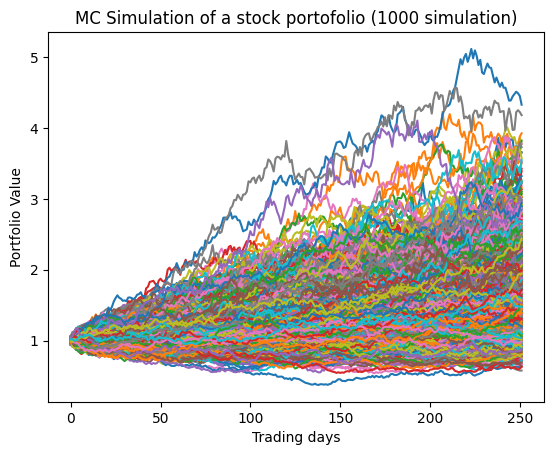

In [4]:
portfolioReturns = np.zeros((252,1000))
initialPortfolio = 10000

for i in range(1000):
    weights = np.random.random(len(stocks))
    weights/= np.sum(weights)
    randDailyReturn = np.random.multivariate_normal(returnsAvg,covMatrix,252)
    simDailyReturns = np.dot(randDailyReturn, weights)
    portfolioReturns[:,i] = np.cumprod(1+simDailyReturns)

plt.plot(portfolioReturns)
plt.title('MC Simulation of a stock portofolio (1000 simulation)')
plt.xlabel('Trading days')
plt.ylabel('Portfolio Value')



In [5]:
finalValues = portfolioReturns[-1,:]
finalValuesmean = finalValues.mean()
var95 = np.percentile(finalValues,5)
best95 = np.percentile(finalValues,95)

print("Simulation Result")
print(f"Mean expected portfolio value: ${finalValuesmean*initialPortfolio}")
print(f"95% Confidence interval (worst Case) ${var95*initialPortfolio}")
print(f"95% Confidence Interval (best case) ${best95*initialPortfolio}")


Simulation Result
Mean expected portfolio value: $16948.531202356466
95% Confidence interval (worst Case) $9211.627165822214
95% Confidence Interval (best case) $28451.563157256365


In [6]:
numPortfolios = 1000
assetsLen = len(stocks)
tradingDays = 252

returnsAll = np.zeros(numPortfolios)
volatilityAll = np.zeros(numPortfolios)
weightsAll = np.zeros((numPortfolios,assetsLen))

for i in range(numPortfolios):
    weights = np.random.random(assetsLen)
    weights /= np.sum(weights)
    returnList = []
    for j in range(tradingDays):
         randDailyReturn = np.random.multivariate_normal(returnsAvg,covMatrix,252)
         simDailyReturns = np.dot(randDailyReturn, weights)
         returnList.append(simDailyReturns)
    DailyReturns = np.array(returnList)
    cumReturns = np.cumprod(1+DailyReturns)
    ar = cumReturns[-1] ** (1/tradingDays)-1
    arVol = np.std(DailyReturns) * np.sqrt(tradingDays)
    returnsAll[i] = ar
    volatilityAll[i] = arVol
    weightsAll[i] = weights
sharpe = returnsAll / volatilityAll
optimal_portfolio_index = sharpe.argmax()
optimal_weights = weightsAll[optimal_portfolio_index]
optimal_returns = returnsAll[optimal_portfolio_index]
optimal_volatility = volatilityAll[optimal_portfolio_index]

MC Portfolio optimization result
Optimal Weights:
BUMI.JK : 0.018071711157006873
DEWA.JK : 0.06606304015439957
BBCA.JK : 0.27675185793881885
PTBA.JK : 0.15230192679895962
PTRO.JK : 0.22883024912428923
MINA.JK : 0.25798121482652586

 Optimal Annualized Returns: 0.8299403801399705

 Optimal Annualized Volatility: 0.3539354621060532

 Optimal sharpe: 2.344891848930603


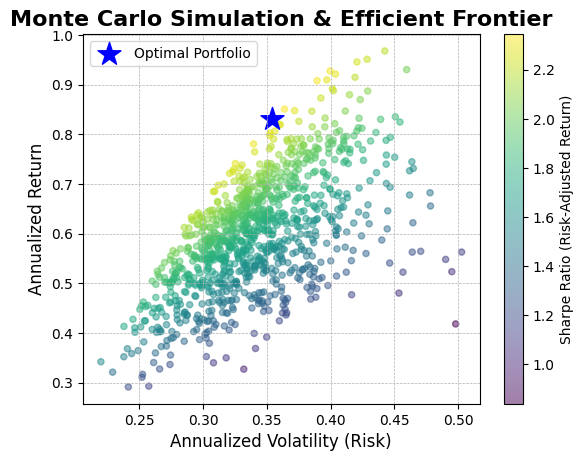

In [7]:
print('MC Portfolio optimization result')
print('Optimal Weights:')

for i in range(len(stocks)):
    print(f"{stocks[i]} : {optimal_weights[i]}")

print(f"\n Optimal Annualized Returns: {optimal_returns}")
print(f"\n Optimal Annualized Volatility: {optimal_volatility}")
print(f"\n Optimal sharpe: {sharpe[optimal_portfolio_index]}")

plt.Figure(figsize=(12,8))
plt.scatter(volatilityAll,returnsAll,c=sharpe,cmap='viridis',s=20,alpha=0.5)
plt.colorbar(label='Sharpe Ratio (Risk-Adjusted Return)')
plt.title('Monte Carlo Simulation & Efficient Frontier', fontsize=16, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.scatter(optimal_volatility, optimal_returns, color='blue', marker='*', s=300, label='Optimal Portfolio')
plt.legend()
plt.show()